Imports

In [1]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from datetime import time

Load 1 Minute of Data from 10:00:00 AM to 10:01:00 AM ET (With Jitter Removed)

In [2]:
query = (
    pl.scan_parquet('spy_mbo.parquet')
    .select(
        pl.col('ts_event').dt.convert_time_zone('America/New_York').dt.replace_time_zone(None),
        pl.col('ts_recv').dt.convert_time_zone('America/New_York').dt.replace_time_zone(None),
        pl.col('ts_in_delta'),
        pl.col('sequence'),
        pl.col('symbol'),
        pl.col('order_id'),
        pl.col('publisher_id'),
        pl.col('action'),
        pl.col('side'),
        pl.col('price'),
        pl.col('size'),
        pl.col('rtype'),
        pl.col('instrument_id'),
        pl.col('channel_id'),
        pl.col('flags')
    )
    .filter(
        pl.col('action').is_in(['A', 'M', 'C', 'R'])
    )
    .filter(
        pl.col('ts_event').dt.time() >= time(10, 00, 00),
        pl.col('ts_event').dt.time() <= time(10, 1, 00)
    )
    .sort(
        pl.col('sequence')
    )
    .with_columns(
        cumulative_maximum_timestamp_sorted_by_sequence=pl.col('ts_event').cum_max().over(pl.col('publisher_id'))
    )
    .sort(
        pl.col('cumulative_maximum_timestamp_sorted_by_sequence'),
        pl.col('publisher_id'),
        pl.col('sequence')
    )
)
market_by_order_data_df = query.collect()
market_by_order_data_df

ts_event,ts_recv,ts_in_delta,sequence,symbol,order_id,publisher_id,action,side,price,size,rtype,instrument_id,channel_id,flags,cumulative_maximum_timestamp_sorted_by_sequence
datetime[μs],datetime[μs],i32,u32,str,u64,u16,str,str,f64,u32,u8,u32,u8,u8,datetime[μs]
2026-03-23 10:00:00.000344,2026-03-23 10:00:00.000551,199366,23939758,"""SPY""",284773571068696,43,"""A""","""B""",660.19,18,160,15144,0,128,2026-03-23 10:00:00.000344
2026-03-23 10:00:00.000353,2026-03-23 10:00:00.000560,199407,23939759,"""SPY""",284773571068705,43,"""A""","""A""",660.23,16,160,15144,0,128,2026-03-23 10:00:00.000353
2026-03-23 10:00:00.000560,2026-03-23 10:00:00.000592,32762,21228992,"""SPY""",3191404863773174854,5,"""A""","""A""",660.23,80,160,15144,23,128,2026-03-23 10:00:00.000560
2026-03-23 10:00:00.000572,2026-03-23 10:00:00.000584,0,105650931,"""SPY""",860838092,15,"""A""","""A""",660.23,80,160,15144,0,128,2026-03-23 10:00:00.000572
2026-03-23 10:00:00.000624,2026-03-23 10:00:00.000791,166466,305195009,"""SPY""",574433116,2,"""C""","""B""",660.2,100,160,15144,0,0,2026-03-23 10:00:00.000624
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-03-23 10:00:59.999066,2026-03-23 10:00:59.999098,32766,8750146,"""SPY""",3191404898117904540,6,"""A""","""B""",660.09,8,160,15144,23,128,2026-03-23 10:00:59.999066
2026-03-23 10:00:59.999160,2026-03-23 10:00:59.999171,0,107308420,"""SPY""",873461905,15,"""A""","""B""",660.09,40,160,15144,0,128,2026-03-23 10:00:59.999160
2026-03-23 10:00:59.999240,2026-03-23 10:00:59.999448,199598,24357141,"""SPY""",284773571611729,43,"""C""","""B""",660.09,100,160,15144,0,128,2026-03-23 10:00:59.999240


Exchange Mapping

In [3]:
# exchange mapping from publisher_id to the exchange description and exchange identification code
exchange_mapping = {
    2: 'Nasdaq (XNAS)',
    3: 'Nasdaq Texas (XBOS)',
    4: 'Nasdaq PSX (XPSX)',
    5: 'Cboe BZX (BATS)',
    6: 'Cboe BYX (BATY)',
    7: 'Cboe EDGA (EDGA)',
    8: 'Cboe EDGX (EDGX)',
    9: 'NYSE (XNYS)',
    11: 'NYSE American (XASE)',
    12: 'NYSE Texas (XCHI)',
    15: 'MEMX MEMOIR (MEMX)',
    16: 'MIAX Pearl (EPRL)',
    43: 'NYSE Arca (ARCX)'
}

Setup Orderbook

In [4]:
# dictionary holding bid and ask limit order queues at each price for all 14 exchanges
publisher_id_list = market_by_order_data_df['publisher_id'].unique()
bids = {publisher_id: {} for publisher_id in publisher_id_list}
asks = {publisher_id: {} for publisher_id in publisher_id_list}

# master tracker of all orders processed from the market by order feed consolidated across all 14 exchanges
# global_id -> {publisher_id, side, price}
order_tracker = {}

# counts the number of orders processed by each of the 14 exchanges 
order_processed_map = {publisher_id: 0 for publisher_id in publisher_id_list}

Reconstruct LOB to Calculate NBBO After Each MBO Order

In [5]:
national_best_bid_list = []
national_best_ask_list = []

for order in market_by_order_data_df.iter_rows(named=True):
    # ensure that a global id is created for each individual exchange so order_id from different exchanges do not conflict in the central limit order book
    global_id = f"{order['publisher_id']}_{order['order_id']}"

    # track the number of orders that have been processed by each of the 14 exchanges 
    order_processed_map[order['publisher_id']] += 1

    ############################ MATCHING ENGINE LOGIC ####################################
    #                                                                                     #
    #                                                                                     #
    #                                                                                     #
    ############################ MATCHING ENGINE LOGIC ####################################

    # add a limit order to the limit order book 
    # a new order_id is created whenever a limit order is added to the limit order book 
    if order['action'] == 'A':
        if global_id not in order_tracker and order['side'] in ['A', 'B'] and order['price'] > 0:
            order_tracker[global_id] = {'publisher_id': order['publisher_id'], 'order_side': order['side'], 'order_price': order['price']}
            book = asks[order['publisher_id']] if order['side'] == 'A' else bids[order['publisher_id']]
            if order['price'] not in book:
                book[order['price']] = []
            book[order['price']].append([global_id, order['size']])
    
    # modify a limit order that is already in the limit order book
    # the order_id is used to track and modify the limit order that already exists in the limit order book 
    elif order['action'] == 'M':
        if global_id not in order_tracker: 
            if order['size'] > 0 and order['side'] in ['A', 'B'] and order['price'] > 0:
                order_tracker[global_id] = {'publisher_id': order['publisher_id'], 'order_side': order['side'], 'order_price': order['price']}
                book = asks[order['publisher_id']] if order['side'] == 'A' else bids[order['publisher_id']]
                if order['price'] not in book:
                    book[order['price']] = []
                book[order['price']].append([global_id, order['size']])
        else:
            old_order_price = order_tracker[global_id]['order_price']
            old_order_side = order_tracker[global_id]['order_side']
            book = asks[order['publisher_id']] if old_order_side == 'A' else bids[order['publisher_id']]

            new_order_price = order['price'] if order['price'] > 0 else old_order_price

            if order['size'] == 0:
                if old_order_price in book:
                    for i, o in enumerate(book[old_order_price]):
                        if o[0] == global_id:
                            book[old_order_price].pop(i)
                            if len(book[old_order_price]) == 0:
                                del book[old_order_price]
                            break
                del order_tracker[global_id]

            elif old_order_price != new_order_price:
                if old_order_price in book:
                    for i, o in enumerate(book[old_order_price]):
                        if o[0] == global_id:
                            book[old_order_price].pop(i)
                            if len(book[old_order_price]) == 0:
                                del book[old_order_price]
                            break
                
                if new_order_price not in book:
                    book[new_order_price] = []
                book[new_order_price].append([global_id, order['size']])
                order_tracker[global_id]['order_price'] = new_order_price

            else:
                if old_order_price in book:
                    for o in book[old_order_price]:
                        if o[0] == global_id:
                            o[1] = order['size']
                            break

    # cancel a limit order that is already in the limit order book 
    # the order_id is used to track and cancel the limit order that already exists in the limit order book
    elif order['action'] == 'C':
        if global_id in order_tracker:
            order_to_cancel_price = order_tracker[global_id]['order_price']
            order_to_cancel_side = order_tracker[global_id]['order_side']
            book = asks[order['publisher_id']] if order_to_cancel_side == 'A' else bids[order['publisher_id']]

            if order_to_cancel_price in book:
                for i, o in enumerate(book[order_to_cancel_price]):
                    if o[0] == global_id:
                        if order['size'] > 0 and order['size'] < o[1]:
                            o[1] -= order['size']
                        else:
                            book[order_to_cancel_price].pop(i)
                            if len(book[order_to_cancel_price]) == 0:
                                del book[order_to_cancel_price]
                            del order_tracker[global_id]
                        break

    # restart limit order book and completely wipe out all limit order books
    # this happens after a circuit breaker where exchanges cancel all limit orders and introduce a call market to allow for new price discovery after large price moves
    elif order['action'] == 'R':
        bids[order['publisher_id']].clear()
        asks[order['publisher_id']].clear()
        # remove all limit orders in the exchange that restarted their limit order book
        # keep the limit orders in all the other exchanges
        order_tracker = {k: v for k, v in order_tracker.items() if v['publisher_id'] != order['publisher_id']}

    ################################# NBBO CALCULATIONS ###################################
    #                                                                                     #
    #                                                                                     #
    #                                                                                     #
    ################################# NBBO CALCULATIONS ###################################

    # calculate the best bid price and best bid size
    exchange_best_bid = []

    for publisher_id in bids:
        publisher_id_max_bid_price = 0
        publisher_id_max_bid_size = 0

        for publisher_id_bid_price in bids[publisher_id]:
            if publisher_id_bid_price > publisher_id_max_bid_price:
                publisher_id_max_bid_price = publisher_id_bid_price
        
        if len(bids[publisher_id]) > 0:
            for publisher_id_bid_size in bids[publisher_id][publisher_id_max_bid_price]:
                publisher_id_max_bid_size += publisher_id_bid_size[1]

        exchange_best_bid.append({
            'publisher_id': publisher_id,
            'best_bid_price': publisher_id_max_bid_price, 
            'best_bid_size': publisher_id_max_bid_size
        })    

    national_best_bid_price = 0
    national_best_bid_size = 0

    for exchange in exchange_best_bid:
        if exchange['best_bid_price'] > national_best_bid_price:
            national_best_bid_price = exchange['best_bid_price']

    for exchange in exchange_best_bid:
        if exchange['best_bid_price'] == national_best_bid_price:
            national_best_bid_size += exchange['best_bid_size']

    national_best_bid_list.append({
        'order_id': order['order_id'],
        'cumulative_maximum_timestamp_sorted_by_sequence': order['cumulative_maximum_timestamp_sorted_by_sequence'],
        'publisher_id': order['publisher_id'],
        'sequence': order['sequence'],
        'national_best_bid_price': national_best_bid_price, 
        'national_best_bid_size': national_best_bid_size
    })

    # calculate the best ask price and best ask size
    exchange_best_ask = []

    for publisher_id in asks:
        publisher_id_min_ask_price = 1e9
        publisher_id_min_ask_size = 0

        for publisher_id_ask_price in asks[publisher_id]:
            if publisher_id_ask_price < publisher_id_min_ask_price:
                publisher_id_min_ask_price = publisher_id_ask_price 
        
        if len(asks[publisher_id]) > 0:
            for publisher_id_ask_size in asks[publisher_id][publisher_id_min_ask_price]:
                publisher_id_min_ask_size += publisher_id_ask_size[1]
        
        exchange_best_ask.append({
            'publisher_id': publisher_id, 
            'best_ask_price': publisher_id_min_ask_price, 
            'best_ask_size': publisher_id_min_ask_size 
        })

    national_best_ask_price = 1e9
    national_best_ask_size = 0

    for exchange in exchange_best_ask:
        if exchange['best_ask_price'] < national_best_ask_price:
            national_best_ask_price = exchange['best_ask_price']

    for exchange in exchange_best_ask:
        if exchange['best_ask_price'] == national_best_ask_price:
            national_best_ask_size += exchange['best_ask_size']

    national_best_ask_list.append({
        'order_id': order['order_id'],
        'cumulative_maximum_timestamp_sorted_by_sequence': order['cumulative_maximum_timestamp_sorted_by_sequence'],
        'publisher_id': order['publisher_id'],
        'sequence': order['sequence'],
        'national_best_ask_price': national_best_ask_price,
        'national_best_ask_size': national_best_ask_size
    })

Merge NBBO Data with Original MBO Data and Calculate National Mid Price and Top of Book Volume Imbalance

In [6]:
national_best_bid_df = pl.DataFrame(national_best_bid_list, orient='row')
national_best_ask_df = pl.DataFrame(national_best_ask_list, orient='row')

merged_df = market_by_order_data_df.filter(
    pl.col('action').is_in(['A', 'M', 'C', 'R'])
).join(
    national_best_bid_df.select(
        pl.col('order_id'),
        pl.col('publisher_id'),
        pl.col('sequence'),
        pl.col('national_best_bid_price'),
        pl.col('national_best_bid_size'),
    ),
    on=['order_id', 'publisher_id', 'sequence'],
    how='left'
).join(
    national_best_ask_df.select(
        pl.col('order_id'),
        pl.col('publisher_id'),
        pl.col('sequence'),
        pl.col('national_best_ask_price'),
        pl.col('national_best_ask_size')
    ),
    on=['order_id', 'publisher_id', 'sequence'],
    how='left'
).with_columns(
    national_mid_price=(pl.col('national_best_bid_price')+pl.col('national_best_ask_price'))/2,
    volume_imbalance=(pl.col('national_best_bid_size')-pl.col('national_best_ask_size'))/(pl.col('national_best_bid_size')+pl.col('national_best_ask_size'))
).with_columns(
    national_mid_price_lag_1=pl.col('national_mid_price').shift(1),
    volume_imbalance_lag_1=pl.col('volume_imbalance').shift(1)
).with_columns(
    national_mid_price_change_1=pl.col('national_mid_price')-pl.col('national_mid_price_lag_1'),
    volume_imbalance_change_1=pl.col('volume_imbalance')-pl.col('volume_imbalance_lag_1')
).filter(
    ~pl.col('national_mid_price_change_1').is_null(),
    pl.col('national_mid_price_lag_1') < 4e8
)

merged_df

ts_event,ts_recv,ts_in_delta,sequence,symbol,order_id,publisher_id,action,side,price,size,rtype,instrument_id,channel_id,flags,cumulative_maximum_timestamp_sorted_by_sequence,national_best_bid_price,national_best_bid_size,national_best_ask_price,national_best_ask_size,national_mid_price,volume_imbalance,national_mid_price_lag_1,volume_imbalance_lag_1,national_mid_price_change_1,volume_imbalance_change_1
datetime[μs],datetime[μs],i32,u32,str,u64,u16,str,str,f64,u32,u8,u32,u8,u8,datetime[μs],f64,i64,f64,i64,f64,f64,f64,f64,f64,f64
2026-03-23 10:00:00.000560,2026-03-23 10:00:00.000592,32762,21228992,"""SPY""",3191404863773174854,5,"""A""","""A""",660.23,80,160,15144,23,128,2026-03-23 10:00:00.000560,660.19,18,660.23,96,660.21,-0.684211,660.21,0.058824,0.0,-0.743034
2026-03-23 10:00:00.000572,2026-03-23 10:00:00.000584,0,105650931,"""SPY""",860838092,15,"""A""","""A""",660.23,80,160,15144,0,128,2026-03-23 10:00:00.000572,660.19,18,660.23,176,660.21,-0.814433,660.21,-0.684211,0.0,-0.130222
2026-03-23 10:00:00.000624,2026-03-23 10:00:00.000791,166466,305195009,"""SPY""",574433116,2,"""C""","""B""",660.2,100,160,15144,0,0,2026-03-23 10:00:00.000624,660.19,18,660.23,176,660.21,-0.814433,660.21,-0.814433,0.0,0.0
2026-03-23 10:00:00.000624,2026-03-23 10:00:00.000791,166466,305195010,"""SPY""",574470768,2,"""C""","""B""",660.2,28,160,15144,0,0,2026-03-23 10:00:00.000624,660.19,18,660.23,176,660.21,-0.814433,660.21,-0.814433,0.0,0.0
2026-03-23 10:00:00.000647,2026-03-23 10:00:00.000811,163726,305195035,"""SPY""",574472944,2,"""A""","""A""",660.21,100,160,15144,0,128,2026-03-23 10:00:00.000647,660.19,18,660.21,100,660.2,-0.694915,660.21,-0.814433,-0.01,0.119518
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-03-23 10:00:59.999066,2026-03-23 10:00:59.999098,32766,8750146,"""SPY""",3191404898117904540,6,"""A""","""B""",660.09,8,160,15144,23,128,2026-03-23 10:00:59.999066,660.09,1588,660.11,780,660.1,0.341216,660.1,0.338983,0.0,0.002233
2026-03-23 10:00:59.999160,2026-03-23 10:00:59.999171,0,107308420,"""SPY""",873461905,15,"""A""","""B""",660.09,40,160,15144,0,128,2026-03-23 10:00:59.999160,660.09,1628,660.11,780,660.1,0.352159,660.1,0.341216,0.0,0.010943
2026-03-23 10:00:59.999240,2026-03-23 10:00:59.999448,199598,24357141,"""SPY""",284773571611729,43,"""C""","""B""",660.09,100,160,15144,0,128,2026-03-23 10:00:59.999240,660.09,1528,660.11,780,660.1,0.32409,660.1,0.352159,0.0,-0.028069


Linear Regression on All MBO Orders

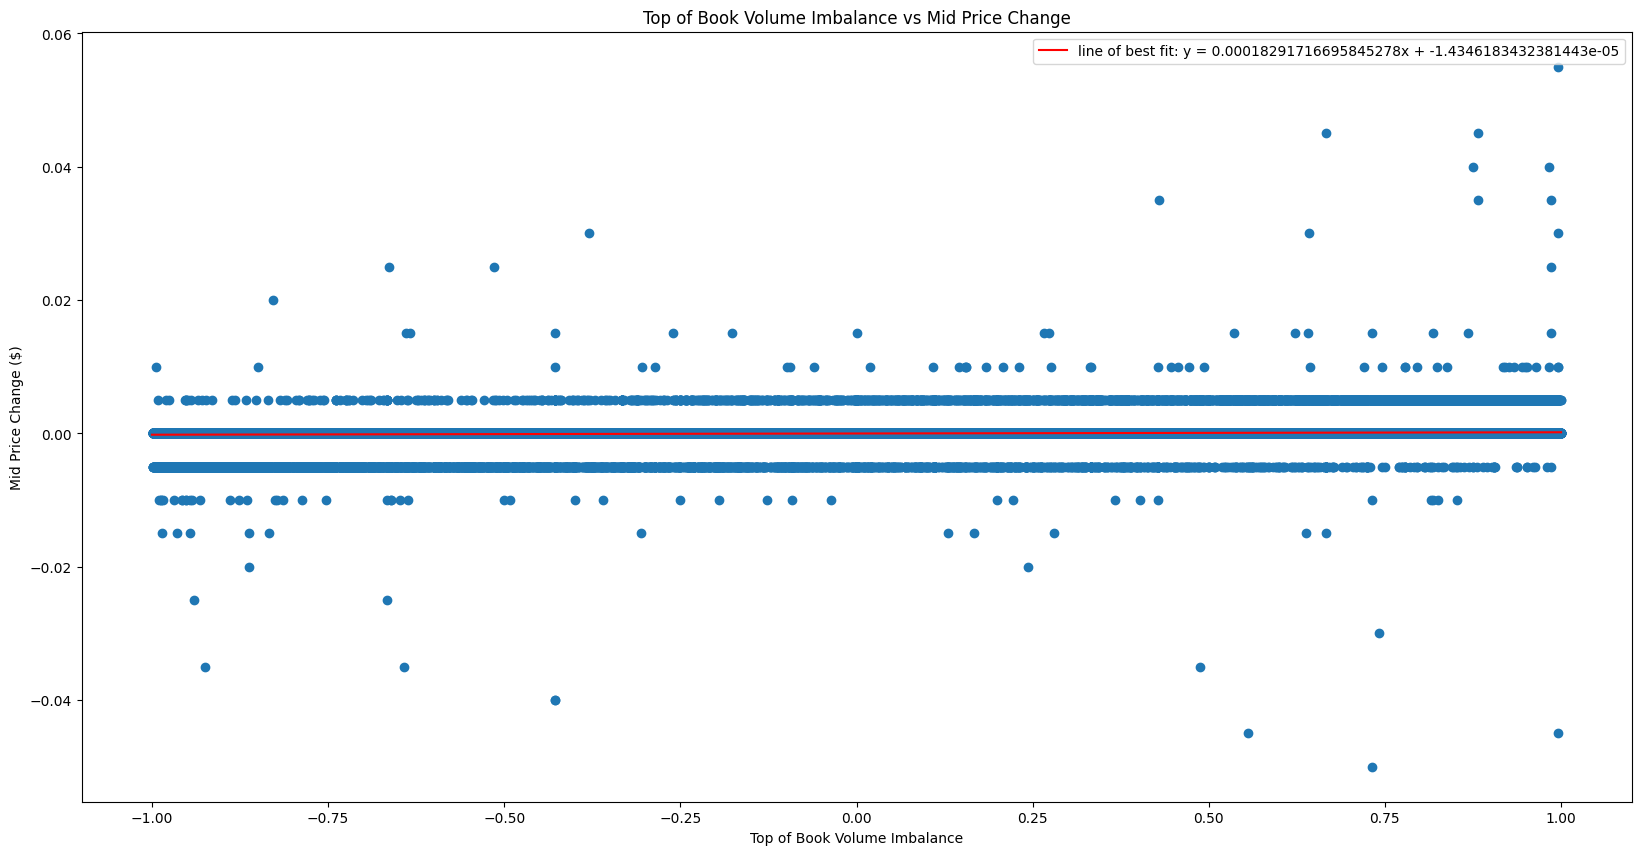

In [7]:
X = merged_df.select(
    pl.col('volume_imbalance_lag_1')
).with_columns(
    constant_value=1
).to_numpy()

Y = merged_df.select(
    pl.col('national_mid_price_change_1')
).to_numpy()

B = np.linalg.inv(X.T @ X) @ X.T @ Y
x = np.linspace(-1, 1, 1000)
y = B[0]*x + B[1]

plt.figure(figsize=(20,10))
plt.scatter(merged_df['volume_imbalance_lag_1'], merged_df['national_mid_price_change_1'])
plt.plot(x, y, color='red', label=f"line of best fit: y = {B[0][0]}x + {B[1][0]}")
plt.xlabel('Top of Book Volume Imbalance')
plt.ylabel('Mid Price Change ($)')
plt.title('Top of Book Volume Imbalance vs Mid Price Change')
plt.legend()
plt.show()

Linear Regression on MBO Orders that Change NBBO

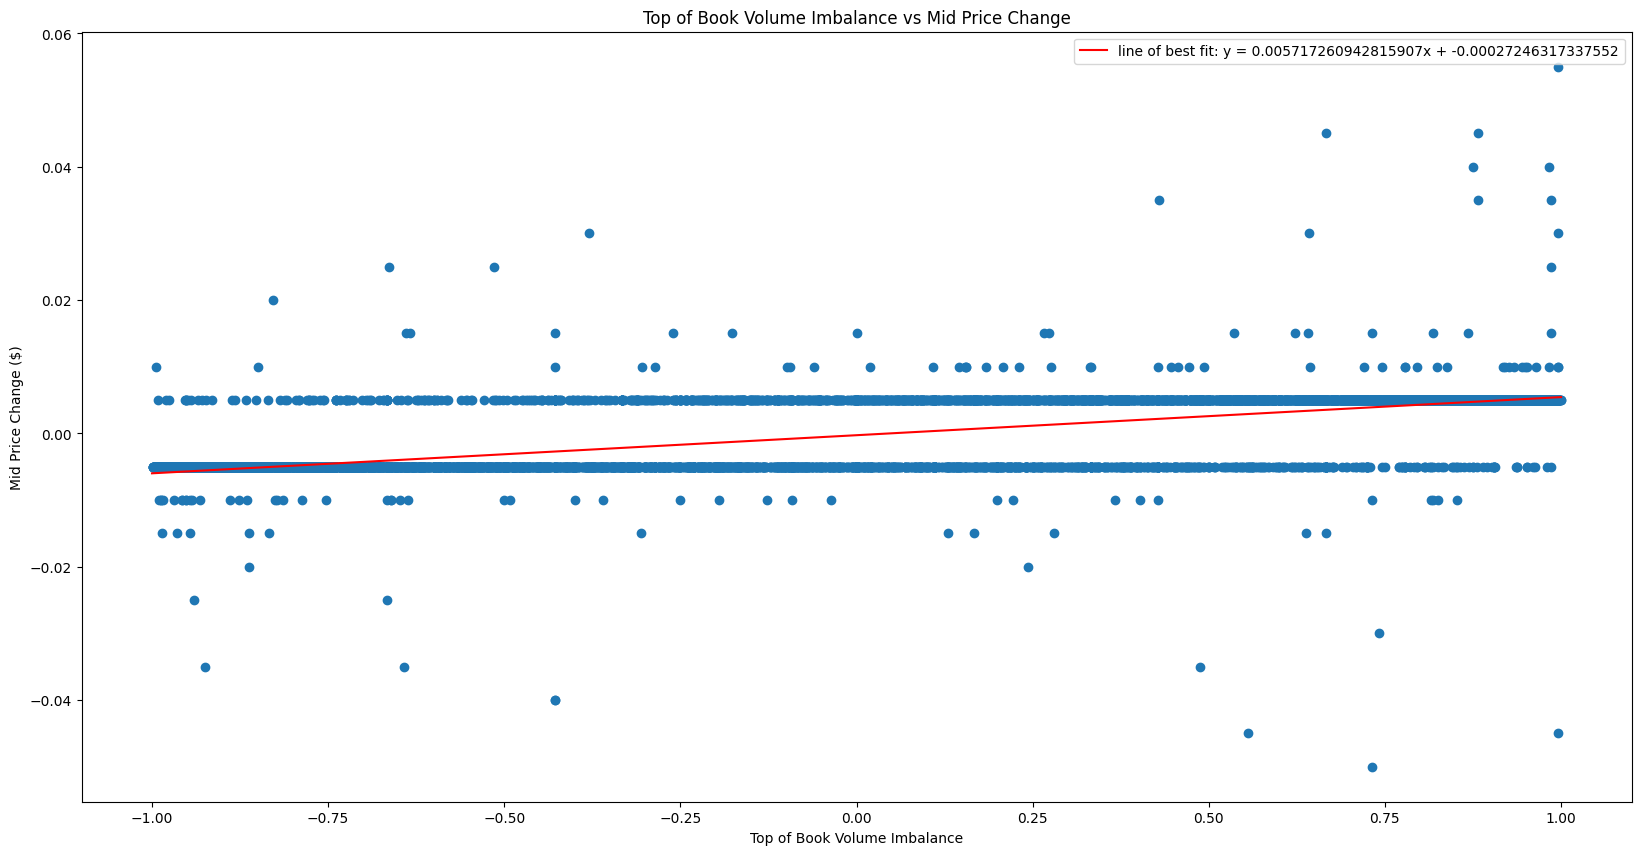

In [8]:
filter_price_df = merged_df.filter(
    pl.col('national_mid_price_change_1') != 0
)

X = filter_price_df.select(
    pl.col('volume_imbalance_lag_1')
).with_columns(
    constant_value=1
).to_numpy()

Y = filter_price_df.select(
    pl.col('national_mid_price_change_1')
).to_numpy()

B = np.linalg.inv(X.T @ X) @ X.T @ Y
x = np.linspace(-1, 1, 1000)
y = B[0]*x + B[1]

plt.figure(figsize=(20,10))
plt.scatter(filter_price_df['volume_imbalance_lag_1'], filter_price_df['national_mid_price_change_1'])
plt.plot(x, y, color='red', label=f"line of best fit: y = {B[0][0]}x + {B[1][0]}")
plt.xlabel('Top of Book Volume Imbalance')
plt.ylabel('Mid Price Change ($)')
plt.title('Top of Book Volume Imbalance vs Mid Price Change')
plt.legend()
plt.show()

Most MBO Orders Submitted to Orderbook do NOT Affect NBBO

In [9]:
# around 2.28% of limit orders affect the national best bid price or the national best ask price
len(filter_price_df) / len(merged_df) * 100

2.2848720448166113